<a href="https://colab.research.google.com/github/miradonkoh/lab_3/blob/main/lab_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [140]:

#NAME: SAMIRA EWURA-ESI DONKOH
#ID: 20962028
#COHORT C
#DR ALBERT DEDE, DANIEL BYIRINGIRO, HUTTON AMISSON ADDY

# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)




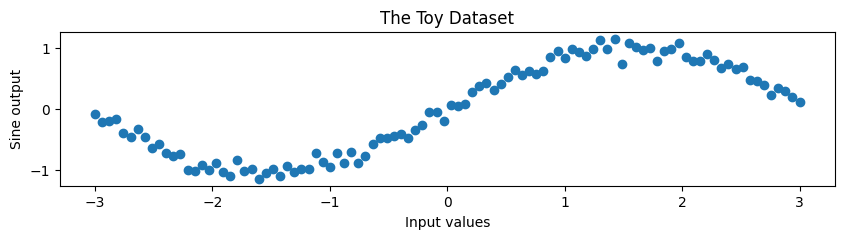

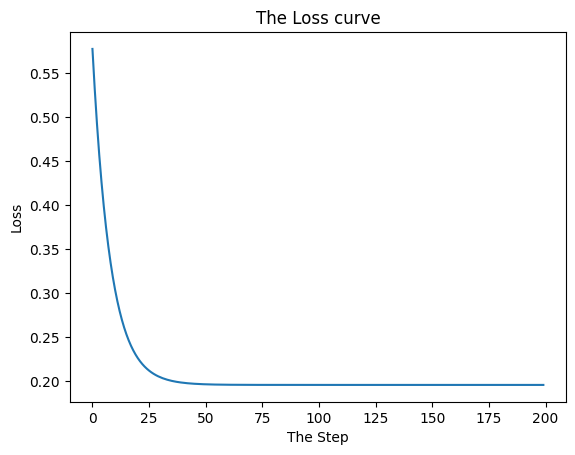

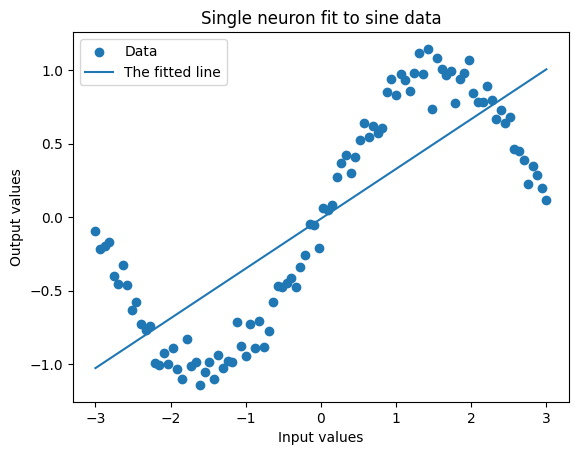

In [141]:
# TODO: Generate the toy data
#   x = np.linspace(-3, 3, 100); y = np.sin(x) + small Gaussian noise (std=0.1)
#   Plot it.
x= np.linspace(-3, 3, 100)
y=np.sin(x)+np.random.normal(0,0.1,100)
plt.figure(figsize=(10,2))
plt.scatter(x,y)
plt.title("The Toy Dataset")
plt.xlabel("Input values")
plt.ylabel("Sine output")
plt.show()
# TODO: Initialise w and b to small random values.
w=np.random.randn()*0.01
b=np.random.randn()*0.01

# TODO: Implement ONE gradient-descent step by hand, then loop it for ~200 steps:
lr=0.01
loss_history=[]
for step in range(200):
  y_hat = w * x + b
  loss  = np.mean((y_hat - y) ** 2)               # MSE
  dw    = np.mean(2 * (y_hat - y) * x)            # dLoss/dw  (derive this on paper!)
  db    = np.mean(2 * (y_hat - y))                # dLoss/db
  w    -= lr * dw
  b    -= lr * db
#Record the loss at every step.
  loss_history.append(loss)

# TODO: Plot (a) the loss curve over the 200 steps, and (b) the data with the fitted line on top.
plt.plot(loss_history)
plt.xlabel("The Step")
plt.ylabel("Loss")
plt.title("The Loss curve")
plt.show()

plt.scatter(x,y,label="Data")
plt.plot(x,w*x+b,label="The fitted line")
plt.xlabel("Input values")
plt.ylabel("Output values")
plt.title("Single neuron fit to sine data")
plt.legend()
plt.show()



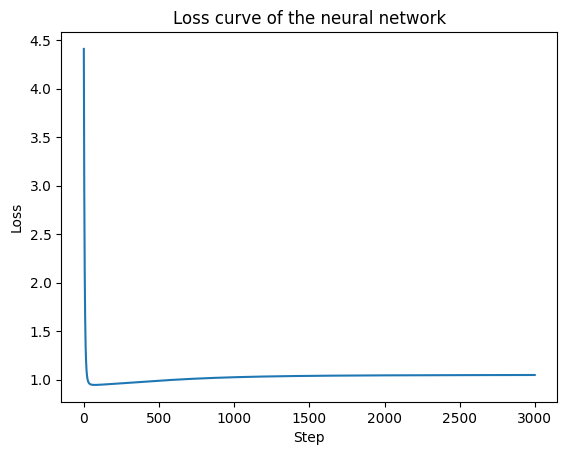

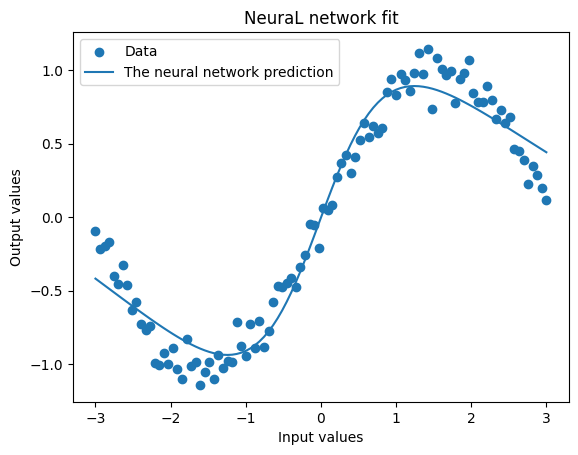

In [142]:
# TODO: Initialise parameters
#   W1: shape (1, 8),  b1: shape (8,)
#   W2: shape (8, 1),  b2: shape (1,)
#   Small random values (e.g. np.random.randn(...) * 0.5)
W1=np.random.randn(1,8)*0.5
b1=np.random.randn(8)*0.5
W2=np.random.randn(8,1)*0.5
b2=np.random.randn(1)*0.5
lr=0.01
X=x.reshape(-1,1)
Y=y.reshape(-1,1)
loss_history=[]
# TODO: Forward pass (keep the intermediate values — you need them for backprop):
for step in range(3000):
  z1 = X @ W1 + b1        # pre-activation, shape (100, 8)
  h  = np.tanh(z1)        # activation
  y_hat = h @ W2 + b2     # output, shape (100, 1)
  loss  = np.mean((y_hat - y) ** 2)
  loss_history.append(loss)
# TODO: Backward pass (the chain rule, layer by layer):
  d_yhat = 2 * (y_hat - Y) / len(Y)
  dW2 = h.T @ d_yhat
  db2 = d_yhat.sum(axis=0)
  dh  = d_yhat @ W2.T
  dz1 = dh * (1 - np.tanh(z1) ** 2)     # derivative of tanh
  dW1 = X.T @ dz1
  db1 = dz1.sum(axis=0)

# TODO: Update all parameters with learning rate lr, loop for ~3000 steps,
#   record the loss.
  W2=W2-lr*dW2
  b2=b2-lr*db2
  W1=W1-lr*dW1
  b1=b1-lr*db1


# TODO: Plot the loss curve AND the final fit over the data.
#   Then re-run with the tanh REMOVED (h = z1). What happens to the fit?
plt.plot(loss_history)
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Loss curve of the neural network")
plt.show()


plt.scatter(x,y,label="Data")
plt.plot(x,y_hat,label="The neural network prediction")
plt.xlabel("Input values")
plt.ylabel("Output values")
plt.title("NeuraL network fit")
plt.legend()
plt.show()



/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:127: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/tmp/ipykernel_988/2254664659.py:17: RuntimeWarning: overflow encountered in square
  loss  = np.mean((y_hat - y) ** 2)
/tmp/ipykernel_988/2254664659.py:23: RuntimeWarning: overflow encountered in matmul
  dh  = d_yhat @ W2.T
/tmp/ipykernel_988/2254664659.py:24: RuntimeWarning: invalid value encountered in multiply
  dz1 = dh * (1 - np.tanh(z1) ** 2)
/usr/local/lib/python3.12/dist-packages/matplotlib/scale.py:253: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


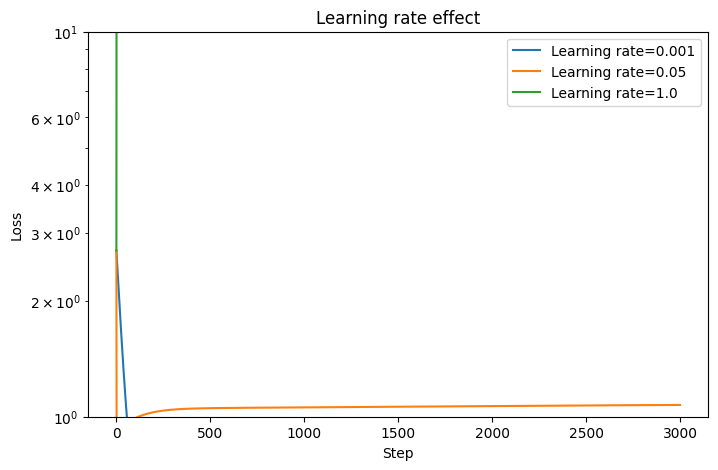

In [143]:
# TODO: Wrap your Part 1.2 training loop in a function train_toy(lr, steps=3000)
#   that returns the list of losses.
def train_toy(lr,steps=3000):
  np.random.seed(RANDOM_STATE)
  W1=np.random.randn(1,8)*0.5
  b1=np.random.randn(8)*0.5
  W2=np.random.randn(8,1)*0.5
  b2=np.random.randn(1)*0.5
  X=x.reshape(-1,1)
  Y=y.reshape(-1,1)
  loss_history=[]

  for step in range(steps):
    z1 = X @ W1 + b1
    h  = np.tanh(z1)
    y_hat = h @ W2 + b2
    loss  = np.mean((y_hat - y) ** 2)
    loss_history.append(loss)

    d_yhat = 2 * (y_hat - Y) / len(Y)
    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis=0)
    dh  = d_yhat @ W2.T
    dz1 = dh * (1 - np.tanh(z1) ** 2)
    dW1 = X.T @ dz1
    db1 = dz1.sum(axis=0)

    W2=W2-lr*dW2
    b2=b2-lr*db2
    W1=W1-lr*dW1
    b1=b1-lr*db1

  return loss_history

# TODO: Run it with THREE learning rates, e.g. lr = 0.001, 0.05, 1.0
#   (keep the same initial weights for a fair comparison — reset the seed).
firstrate=lr =train_toy(lr= 0.001)
secondrate=train_toy(lr= 0.05)
thirdrate=train_toy(lr= 1.0)

# TODO: Plot the three loss curves on the same axes (log scale on y helps), with a legend.
plt.figure(figsize=(8,5))
plt.plot(firstrate,label="Learning rate=0.001")
plt.plot(secondrate,label="Learning rate=0.05")
plt.plot(thirdrate,label="Learning rate=1.0")
plt.yscale("log")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Learning rate effect")
plt.legend()
plt.show()

In [144]:
# TODO: Load the obesity dataset (same OBESITY_URL as Lab 2).

import pandas as pd
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"
obesity = pd.read_csv(OBESITY_URL)
# TODO: Encode categoricals exactly as you did in Lab 2
#   (binary yes/no -> 0/1; Gender/MTRANS/CAEC/CALC -> your justified choice).
#   Encode the target NObeyesdad into integers 0..6 (LabelEncoder) — CrossEntropyLoss
#   expects integer class indices.
encodedobesity=obesity.copy()

binarycols=["family_history_with_overweight","FAVC","SMOKE","SCC"]
for col in binarycols:
  encodedobesity[col]=encodedobesity[col].map({"yes":1,"no":0})
encodedobesity=pd.get_dummies(encodedobesity,columns=["Gender","MTRANS"],drop_first=True)


encodedobesity["CAEC"]=encodedobesity["CAEC"].map({"no":0,"sometimes":1,"frequently": 2,"always": 3})
encodedobesity["CALC"]=encodedobesity["CALC"].map({"no":0,"sometimes":1,"frequently":2,"always":3})

from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()
encodedobesity["NObeyesdad"]=encoder.fit_transform(encodedobesity["NObeyesdad"])



# TODO: Stratified train / validation / test split (60/20/20, stratify=y,
#   random_state=RANDOM_STATE).
X=encodedobesity.drop("NObeyesdad",axis=1)
y= encodedobesity["NObeyesdad"]

from sklearn.model_selection import train_test_split
Xtrain, Xtemp, ytrain, ytemp = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)
Xval, Xtest, yval, ytest = train_test_split(Xtemp, ytemp, test_size=0.5, random_state=42, stratify=ytemp)
train_means = Xtrain.mean()

Xtrain = Xtrain.fillna(train_means)
Xval = Xval.fillna(train_means)
Xtest = Xtest.fillna(train_means)

# TODO: Fit a StandardScaler on the TRAINING set only; transform all three splits.
#   (Neural networks are far more sensitive to feature scale than random forests —
#    remember Section 1, where all gradients depended on x!)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
Xtrainscaled = scaler.fit_transform(Xtrain)
Xvalidatedscaled = scaler.transform(Xval)
Xtestscaled = scaler.transform(Xtest)
# TODO: Convert to tensors and wrap in DataLoaders:
#   X -> torch.float32, y -> torch.long
#   train_loader (batch_size=32, shuffle=True), val_loader, test_loader

Xtraintensor = torch.tensor(Xtrainscaled, dtype=torch.float32)
Xvaltensor = torch.tensor(Xvalidatedscaled, dtype=torch.float32)
Xtesttensor = torch.tensor(Xtestscaled, dtype=torch.float32)

ytraintensor = torch.tensor(ytrain.values, dtype=torch.long)
yvaltensor = torch.tensor(yval.values, dtype=torch.long)
ytesttensor = torch.tensor(ytest.values, dtype=torch.long)



traindataset = TensorDataset(Xtraintensor, ytraintensor)
valdataset = TensorDataset(Xvaltensor, yvaltensor)
testdataset = TensorDataset(Xtesttensor, ytesttensor)

train_loader=DataLoader(traindataset,batch_size=32,shuffle=True)
val_loader=DataLoader(valdataset,batch_size=32,shuffle=False)
test_loader=DataLoader(testdataset,batch_size=32, shuffle=False)







In [145]:
# TODO: Define a FeedForwardNet class (subclass nn.Module) with:
#   - constructor args: input_dim, hidden_sizes=(64, 32), n_classes=7
#   - at least TWO hidden layers with ReLU activations
#   - output layer producing 7 raw logits
#     (NO softmax — nn.CrossEntropyLoss applies log-softmax internally)

# class FeedForwardNet(nn.Module):
#     def __init__(self, ...):
#         ...
#     def forward(self, x):
#         ...
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
class FeedForwardNet(nn.Module):
    def __init__(self, input_dim, hidden_sizes=(64,32), n_classes=7, dropout=0.0):
        super().__init__()

        layers = []
        prev_dim = input_dim

        for hidden_dim in hidden_sizes:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.ReLU())

            if dropout > 0:
                layers.append(nn.Dropout(dropout))

            prev_dim = hidden_dim

        layers.append(nn.Linear(prev_dim, n_classes))

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


# TODO: Instantiate, move to DEVICE, print the model.

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_dim = Xtraintensor.shape[1]
model = FeedForwardNet(input_dim).to(DEVICE)
print(model)

# TODO: Count trainable parameters:
#   sum(p.numel() for p in model.parameters() if p.requires_grad)
#   Verify the count for the FIRST layer by hand: input_dim * 64 + 64.
totalparameters = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Total number of trainable parameters:", totalparameters)



FeedForwardNet(
  (network): Sequential(
    (0): Linear(in_features=19, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=7, bias=True)
  )
)
Total number of trainable parameters: 3591


Epoch 1/50 - Train Loss: 1.8997 - Train Accuracy: 0.2227 - Val Loss: 1.8356 - Val Accuracy: 0.2986
Epoch 2/50 - Train Loss: 1.7332 - Train Accuracy: 0.3918 - Val Loss: 1.6441 - Val Accuracy: 0.4787
Epoch 3/50 - Train Loss: 1.4778 - Train Accuracy: 0.5466 - Val Loss: 1.3564 - Val Accuracy: 0.6019
Epoch 4/50 - Train Loss: 1.1701 - Train Accuracy: 0.6264 - Val Loss: 1.0892 - Val Accuracy: 0.6517
Epoch 5/50 - Train Loss: 0.9417 - Train Accuracy: 0.6761 - Val Loss: 0.9175 - Val Accuracy: 0.6706
Epoch 6/50 - Train Loss: 0.7717 - Train Accuracy: 0.7393 - Val Loss: 0.7781 - Val Accuracy: 0.7536
Epoch 7/50 - Train Loss: 0.6467 - Train Accuracy: 0.7883 - Val Loss: 0.6928 - Val Accuracy: 0.7749
Epoch 8/50 - Train Loss: 0.5534 - Train Accuracy: 0.8167 - Val Loss: 0.6371 - Val Accuracy: 0.7915
Epoch 9/50 - Train Loss: 0.4781 - Train Accuracy: 0.8499 - Val Loss: 0.5837 - Val Accuracy: 0.8318
Epoch 10/50 - Train Loss: 0.4239 - Train Accuracy: 0.8665 - Val Loss: 0.5502 - Val Accuracy: 0.8483
Epoch 11/

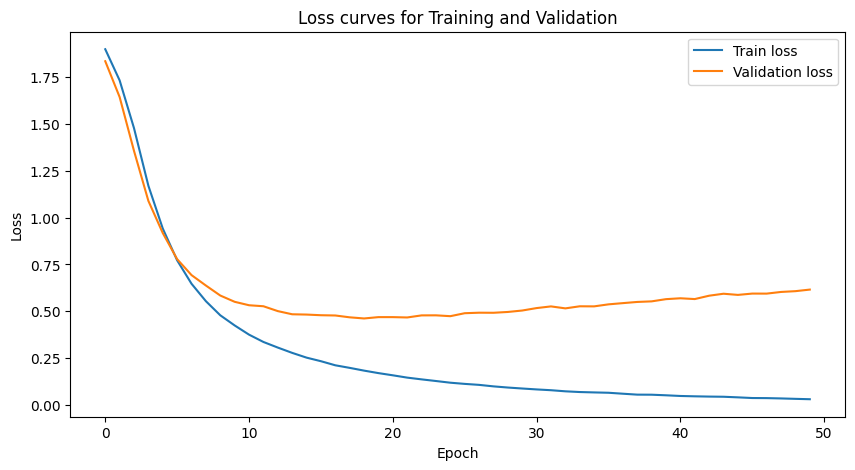

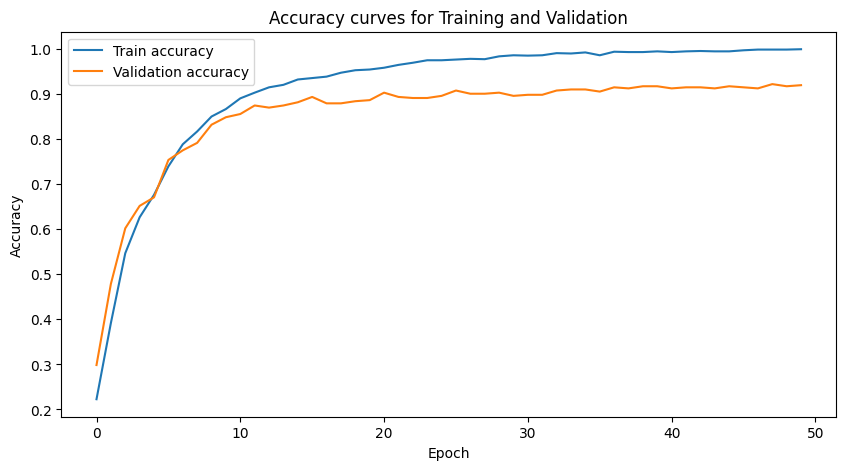

In [146]:
# TODO: criterion = nn.CrossEntropyLoss()
#       optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)   # or SGD — justify
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# TODO: Train for at least 50 epochs. Each epoch:
#   1. model.train(); for xb, yb in train_loader:
#        optimizer.zero_grad()
#        logits = model(xb.to(DEVICE))
#        loss = criterion(logits, yb.to(DEVICE))
#        loss.backward()          # <- the backprop you wrote by hand in Part 1.2
#        optimizer.step()         # <- the update rule you wrote in Part 1.1
#   2. model.eval() + torch.no_grad(): compute loss AND accuracy on train and validation sets
#   3. Append everything to history lists; print a one-line summary per epoch.
trainlosses=[]
trainaccuracies=[]
vallosses=[]
valaccuracies=[]
bestvalaccuracy=0
epochs=50
for epoch in range(epochs):
  model.train()
  runningloss = 0
  correct = 0
  total=0
  for xb,yb in train_loader:
    xb=xb.to(DEVICE)
    yb=yb.to(DEVICE)
    optimizer.zero_grad()
    logits=model(xb)
    loss=criterion(logits,yb)
    loss.backward()
    optimizer.step()
    runningloss += loss.item()
    predicted = torch.argmax(logits,dim=1)
    total += yb.size(0)
    correct += (predicted == yb).sum().item()
  trainloss = runningloss/len(train_loader)
  trainaccuracy = correct/total

  model.eval()
  valloss=0
  valcorrect=0
  valtotal=0
  with torch.no_grad():
    for xb,yb in val_loader:
      xb=xb.to(DEVICE)
      yb=yb.to(DEVICE)
      logits=model(xb)
      loss=criterion(logits,yb)
      valloss+=loss.item()
      predicted=torch.argmax(logits,dim=1)
      valtotal+=yb.size(0)
      valcorrect+=(predicted==yb).sum().item()
  valloss=valloss/len(val_loader)
  valaccuracy=valcorrect/valtotal
  trainlosses.append(trainloss)
  trainaccuracies.append(trainaccuracy)
  vallosses.append(valloss)
  valaccuracies.append(valaccuracy)
# TODO: Save the best model (highest validation accuracy):
#   torch.save(model.state_dict(), "ffn_best.pt")
  if valaccuracy > bestvalaccuracy:
    bestvalaccuracy = valaccuracy
    torch.save(model.state_dict(), "ffn_best.pt")
    print(f"Epoch {epoch+1}/{epochs} - Train Loss: {trainloss:.4f} - Train Accuracy: {trainaccuracy:.4f} - Val Loss: {valloss:.4f} - Val Accuracy: {valaccuracy:.4f}")

# TODO: Plot loss curves (train + val) and accuracy curves (train + val), with legends.


plt.figure(figsize=(10,5))
plt.plot(trainlosses,label="Train loss")
plt.plot(vallosses,label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss curves for Training and Validation")
plt.legend()
plt.show()

plt.figure(figsize=(10,5))
plt.plot(trainaccuracies,label="Train accuracy")
plt.plot(valaccuracies,label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy curves for Training and Validation")
plt.legend()
plt.show()



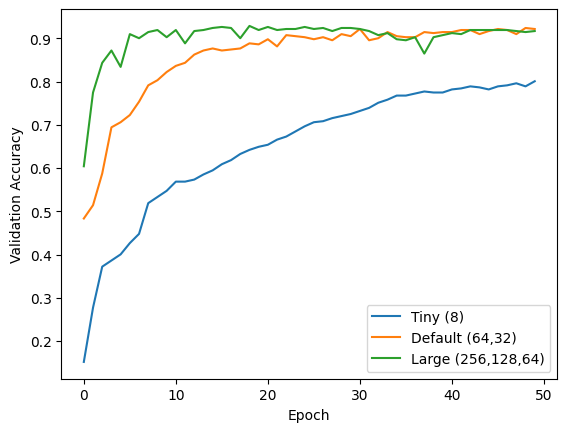

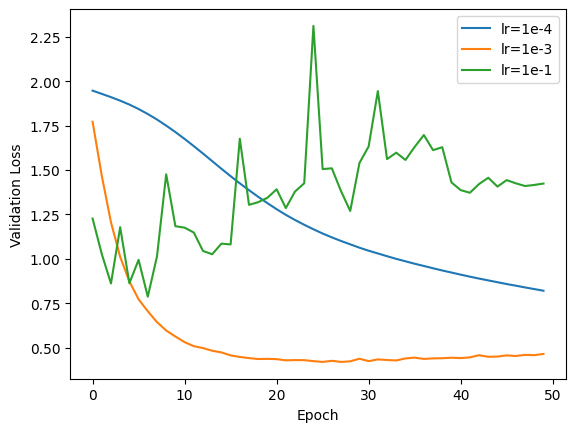

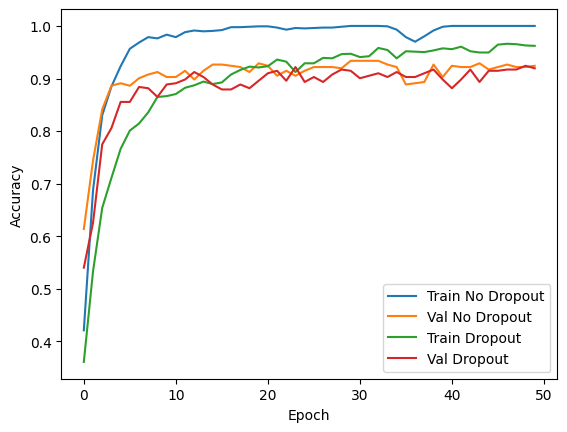

In [147]:
# Wrap your Part 2.3 loop in a function first:
#   def run_experiment(hidden_sizes=(64, 32), lr=1e-3, batch_size=32, epochs=50, dropout=0.0):
#       ... returns history dict ...
def run_experiment(hidden_sizes=(64, 32), lr=1e-3, batch_size=32, epochs=50, dropout=0.0):
  model = FeedForwardNet(input_dim, hidden_sizes, n_classes=7, dropout=dropout).to(DEVICE)
  criterion=nn.CrossEntropyLoss()
  optimizer=torch.optim.Adam(model.parameters(),lr=lr)
  history={
    "trainloss": [],
    "valloss": [],
    "trainaccuracy": [],
    "valaccuracy": []}
  for epoch in range(epochs):
    model.train()
    runningloss = 0
    correct = 0
    total = 0
    for xb,yb in train_loader:
      xb=xb.to(DEVICE)
      yb=yb.to(DEVICE)
      optimizer.zero_grad()
      logits=model(xb)
      loss=criterion(logits,yb)
      loss.backward()
      optimizer.step()
      runningloss += loss.item()
      predicted = torch.argmax(logits,dim=1)
      total += yb.size(0)
      correct += (predicted == yb).sum().item()
    trainloss = runningloss/len(train_loader)
    trainaccuracy = correct/total
    model.eval()
    valloss=0
    valcorrect=0
    valtotal=0
    with torch.no_grad():
        for xb,yb in val_loader:
          xb=xb.to(DEVICE)
          yb=yb.to(DEVICE)
          logits=model(xb)
          loss=criterion(logits,yb)
          valloss+=loss.item()
          predicted=torch.argmax(logits,dim=1)
          valtotal+=yb.size(0)
          valcorrect+=(predicted==yb).sum().item()
    valloss=valloss/len(val_loader)
    valaccuracy=valcorrect/valtotal
    history["trainloss"].append(trainloss)
    history["trainaccuracy"].append(trainaccuracy)
    history["valloss"].append(valloss)
    history["valaccuracy"].append(valaccuracy)
  return history





# TODO — Experiment A (capacity): tiny (8,) vs default (64, 32) vs large (256, 128, 64).
#   Plot the three validation-accuracy curves together.
tiny = run_experiment(hidden_sizes=(8,))
default = run_experiment(hidden_sizes=(64,32))
large = run_experiment(hidden_sizes=(256,128,64))

plt.plot(tiny["valaccuracy"], label="Tiny (8)")
plt.plot(default["valaccuracy"], label="Default (64,32)")
plt.plot(large["valaccuracy"], label="Large (256,128,64)")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.show()
# TODO — Experiment B (learning rate): lr = 1e-4, 1e-3, 1e-1 (same architecture).
#   Plot the three validation-loss curves together. Compare with Part 1.3.
smalllr = run_experiment(lr=1e-4)
defaultlr = run_experiment(lr=1e-3)
largelr = run_experiment(lr=1e-1)


plt.plot(smalllr["valloss"], label="lr=1e-4")
plt.plot(defaultlr["valloss"], label="lr=1e-3")
plt.plot(largelr["valloss"], label="lr=1e-1")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.show()

# TODO — Experiment C (regularization): take your LARGEST network and train it
#   with and without nn.Dropout(0.3) after each hidden layer.
#   Plot train vs validation accuracy for both runs.
nodropout = run_experiment(hidden_sizes=(256,128,64),dropout=0.0)
dropout = run_experiment(hidden_sizes=(256,128,64),dropout=0.3)
plt.plot(nodropout["trainaccuracy"], label="Train No Dropout")
plt.plot(nodropout["valaccuracy"], label="Val No Dropout")
plt.plot(dropout["trainaccuracy"], label="Train Dropout")
plt.plot(dropout["valaccuracy"], label="Val Dropout")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

Accuracy:  0.9385342789598109
MACRO-F1:  0.9364726108581997


<Figure size 1000x1000 with 0 Axes>

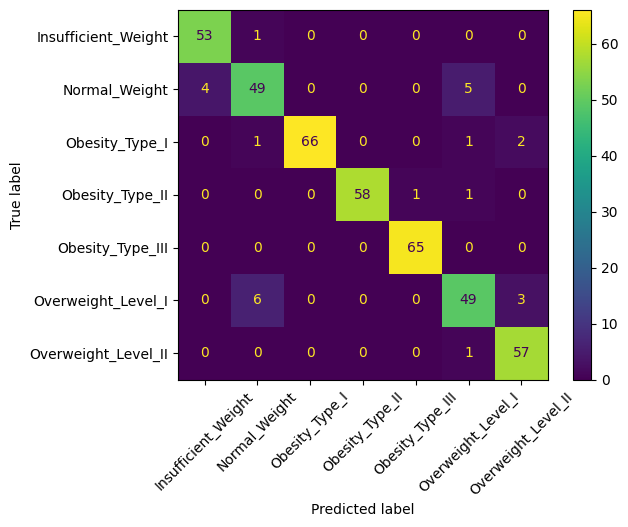

                 Model  Test Accuracy  Test Macro-F1 Training Time  \
0  Logistic regression       0.801418       0.786214  Not measured   
1       Neural network       0.938534       0.936473    Unmeasured   

  Number of Parameters/Trees  
0                        N/a  
1                       3591  


In [148]:
# TODO: Load your best configuration's weights; model.eval().
model.load_state_dict(torch.load("ffn_best.pt"))
model.eval()
# TODO: Report test ACCURACY and MACRO-F1
#   from sklearn.metrics import accuracy_score, f1_score, classification_report
ypred = []
ytrue = []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)
        logits = model(xb)
        predicted = torch.argmax(logits, dim=1)
        ypred.extend(predicted.cpu().numpy())
        ytrue.extend(yb.cpu().numpy())
from sklearn.metrics import accuracy_score, f1_score, classification_report
testaccuracy=accuracy_score(ytrue,ypred)
testf1=f1_score(ytrue,ypred,average="macro")
print("Accuracy: ",testaccuracy)
print("MACRO-F1: ",testf1)

# TODO: Confusion matrix for the test set with the 7 class names
#   from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
plt.figure(figsize=(10,10))
confusionmatrix= ConfusionMatrixDisplay.from_predictions(ytrue, ypred, display_labels=encoder.classes_,xticks_rotation=45)
plt.show()
# TODO: Build a small comparison table (a pandas DataFrame is fine):
#   rows = [your best Lab 2 classifier, this neural network]
#   cols = [test accuracy, test macro-F1, training time, number of parameters/trees]
comparison=pd.DataFrame([["Logistic regression",0.8014184397163121,  0.786213786499504,"Not measured","N/a"],
                         ["Neural network",testaccuracy,testf1,"Unmeasured",totalparameters]],
                         columns=["Model","Test Accuracy","Test Macro-F1","Training Time","Number of Parameters/Trees"])
print(comparison)


 SECTION 3
 1. loss.backward() calculate sgradients of the loss with respect to the parameters and optimizer.step() uses these gradients to update the weight. They both reduce the loss, to allow the model to learn effectively,
 2. I will pick learning rate, because, it has the power to control how fast and effective a model will learn. If the learning rate is poor, training the model becomes too slow.
 3. Across the largest network. Dropout reduced the gap the most by improving generalisation.
 4. It might struggle with images because a plain MLP treats pixels as independent and ignores the spatial relationships. A better architecture should have the ability to detect local patterns.

STUDENT REASONING QUESTIONS

1.1  
1. It matches the code.
2. The model is underfitting. A single neuron computes only a linear function, but a sine wave is not linear, since it has peaks and troughs, so it cant be represented with a straight line.

1.2
1. first layer, h=W1x+b1
   second layer,y=W2h+b2
   after substituting first into second
   y=W2(W1x+b1)+b2
   y=(W2W1)x + (W2b1+b2)
   which can be rewriiten as y=Wx+b, which is linear, so it performs just like a single neuron.
2. The hidden layers 8 neurons used tanh to learn different nonlinear features of the input.
3. Backpropagation is an algorithm that trains neural networks by performing a forward pass to compute predictions, calculate the loss and a backward pass to compute the gradient using the chain rule.

1.3

     lr=0.001 was small, so the loss decreased slowly and the model took a long time to learn.

     lr=0.05 was the best because there was a quick decrease in loss which merged smoothly to a low value.

     lr=1.0 was large so the loss increased instead of converging, due to the overshooting of the minimum loss function.

2.1
1. CrossEntropyLoss uses integer class labels to identify the correct class, so one hot encoding isnt necessary.
2. Neural networks care so much because they use gradients to update the weights, so feauture scaling is important to keep the gradient stable. Random forest on the other hand are not reliant on gradient so feature scaling has little effect.
3. It helps reduce overfitting by randomly rearranging training data.

2.2
1. firstlayer=(19 x 64)+64= 1280 parameters
second layer=(64 x 32)+32= 2080 parameters
third layer=(32 x 7)+7=231 parameters
1280+2080+231= 3591
and this matches PyTorch.
2. ReLU is preferred to tanh here because it is faster, and its advantage is that it reduces the issue of vanishing gradient.
3. Without ReLU the network will be equivalent to a single linear layer, so it will only learn linear relationships.



2.3

 1. logits=model(xb) is the forward pass.

  loss.backward() computes the gradient.

  optimizer.step() is the update rule, that basically updates the weights.

2. It is slightly overfitting. At epoch 48, the training accuracy was 0.9984 and rhe loss was 0.0339 and the validation accuracy was 0.9128 and a loss of 0.6028. The gap among the training and validation shows that the model is learning the training data more than data it has not seen before.

3. optimizer.zero_grad() is called every batch because it clears previous gradients before each batch. Without it, PyTorch will add earlier gradients, which will lead to poor training.


2.4
1. Not really. Signs of overfititng were seen when training accuracy kept improving and validation performane stopped improving.

2. Yes the three regimes match what i saw on the toy problem in Part 1.3 .

3. Dropout lowered training accuracy to reduce the gap between training and validation performance. It works by disabling randomly a few neurons during training, to reduce overfitting.

2.5
1. The network confuses the obesity levels with similar characteristics.And yes they are the same ones the lab 2  classifier confused.
2. The neural network wins since it performed better than the classical model. The extra effort of deep learning was not worth it, because the classical model performed well regardless of it.

